In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [2]:
df = pd.read_csv("News_Final.csv")
df.head()

,IDLink,Title,Headline,Source,Topic,PublishDate,SentimentTitle,SentimentHeadline,Facebook,GooglePlus,LinkedIn
0,99248.0,Obama Lays Wreath at Arlington National Cemetery,Obama Lays Wreath at Arlington National Cemete...,USA TODAY,obama,2002-04-02 00:00:00,0.000000,-0.053300,-1,-1,-1
1,10423.0,A Look at the Health of the Chinese Economy,"Tim Haywood, investment director business-unit...",Bloomberg,economy,2008-09-20 00:00:00,0.208333,-0.156386,-1,-1,-1
2,18828.0,Nouriel Roubini: Global Economy Not Back to 2008,"Nouriel Roubini, NYU professor and chairman at...",Bloomberg,economy,2012-01-28 00:00:00,-0.425210,0.139754,-1,-1,-1
3,27788.0,Finland GDP Expands In Q4,Finland's economy expanded marginally in the t...,RTT News,economy,2015-03-01 00:06:00,0.000000,0.026064,-1,-1,-1
4,27789.0,"Tourism, govt spending buoys Thai economy in J...",Tourism and public spending continued to boost...,The Nation - Thailand&#39;s English news,economy,2015-03-01 00:11:00,0.000000,0.141084,-1,-1,-1


In [3]:
df.shape

(93239, 11)

In [4]:
df.columns = df.columns.str.strip()
df.columns.tolist()

['IDLink',
 'Title',
 'Headline',
 'Source',
 'Topic',
 'PublishDate',
 'SentimentTitle',
 'SentimentHeadline',
 'Facebook',
 'GooglePlus',
 'LinkedIn']

In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
Source,279
Headline,15
IDLink,0
Title,0
Topic,0
PublishDate,0
SentimentTitle,0
SentimentHeadline,0
Facebook,0
GooglePlus,0


In [6]:
duplicate_count = df.duplicated().sum()
# duplicate_count

df = df.drop_duplicates()

In [7]:
social_cols = ["Facebook", "GooglePlus", "LinkedIn"]
df[social_cols].describe()

,Facebook,GooglePlus,LinkedIn
count,93235.000000,93235.000000,93235.000000
mean,113.146200,3.888540,16.548678
std,620.186091,18.493025,154.462322
min,-1.000000,-1.000000,-1.000000
25%,0.000000,0.000000,0.000000
50%,5.000000,0.000000,0.000000
75%,33.000000,2.000000,4.000000
max,49211.000000,1267.000000,20341.000000


In [8]:
# -1 reperesents missing or couldn't find source

social_cols = ["Facebook", "GooglePlus", "LinkedIn"]
df[social_cols] = df[social_cols].replace(-1, np.nan)

df[social_cols].describe()

,Facebook,GooglePlus,LinkedIn
count,81634.000000,87492.000000,87491.000000
mean,129.367506,4.209425,17.700792
std,661.193274,19.046497,159.384622
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,8.000000,0.000000,0.000000
75%,44.000000,2.000000,4.000000
max,49211.000000,1267.000000,20341.000000


In [9]:
df["total_engagement"] = df[social_cols].sum(axis=1, skipna=True, min_count=1)
df["total_engagement"].describe()

,total_engagement
count,87492.000000
mean,142.615759
std,679.904601
min,0.000000
25%,1.000000
50%,11.000000
75%,60.000000
max,49211.000000


In [10]:
df = df.dropna(subset=["total_engagement"])
df.shape[0]

87492

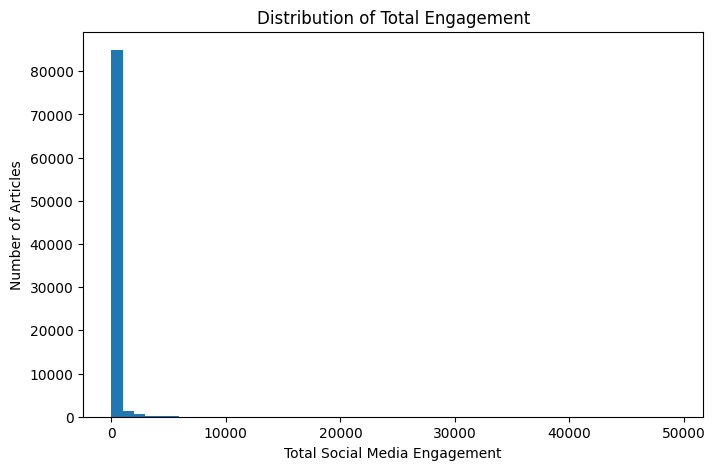

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["total_engagement"], bins=50)
plt.xlabel("Total Social Media Engagement")
plt.ylabel("Number of Articles")
plt.title("Distribution of Total Engagement")
plt.show()

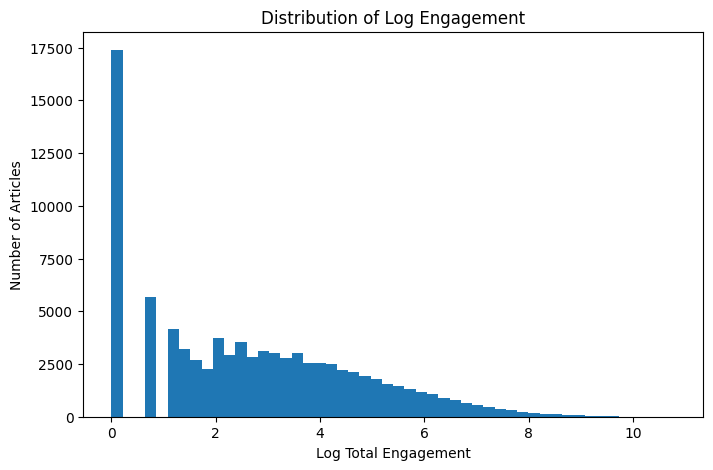

In [12]:
df["log_engagement"] = np.log1p(df["total_engagement"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_engagement"], bins=50)
plt.xlabel("Log Total Engagement")
plt.ylabel("Number of Articles")
plt.title("Distribution of Log Engagement")
plt.show()

In [13]:
threshold = df["total_engagement"].quantile(0.75)

df["popular"] = (df["total_engagement"] >= threshold).astype(int)

print("Popularity threshold:", threshold)
print(df["popular"].value_counts())
print(df["popular"].value_counts(normalize=True))

Popularity threshold: 60.0
popular
0    65436
1    22056
Name: count, dtype: int64
popular
0    0.747908
1    0.252092
Name: proportion, dtype: float64


In [14]:
text_cols = ["Title", "Headline"]

for col in text_cols:
    df[col] = df[col].fillna("")

In [15]:
cat_cols = ["Source", "Topic"]

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [16]:
num_cols = ["SentimentTitle", "SentimentHeadline"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [17]:
df["title_length"] = df["Title"].str.len()
df["headline_length"] = df["Headline"].str.len()

df["title_word_count"] = df["Title"].str.split().str.len()
df["headline_word_count"] = df["Headline"].str.split().str.len()

In [18]:
df["PublishDate"] = pd.to_datetime(df["PublishDate"], errors="coerce")

df["publish_month"] = df["PublishDate"].dt.month
df["publish_dayofweek"] = df["PublishDate"].dt.dayofweek
df["publish_hour"] = df["PublishDate"].dt.hour

In [19]:
date_cols = ["publish_month", "publish_dayofweek", "publish_hour"]

for col in date_cols:
    df[col] = df[col].fillna(df[col].median())

In [20]:
drop_cols = [
    "IDLink",
    "PublishDate",
    "Facebook",
    "GooglePlus",
    "LinkedIn",
    "total_engagement",
    "log_engagement",
    "popular"
]

X = df.drop(columns=drop_cols)
y = df["popular"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87492, 13)
y shape: (87492,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 69993
Testing rows: 17499


In [22]:
print("Training class balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting class balance:")
print(y_test.value_counts(normalize=True))

Training class balance:
popular
0    0.747903
1    0.252097
Name: proportion, dtype: float64

Testing class balance:
popular
0    0.747928
1    0.252072
Name: proportion, dtype: float64


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

text_features = ["Title", "Headline"]
categorical_features = ["Source", "Topic"]
numeric_features = [
    "SentimentTitle",
    "SentimentHeadline",
    "title_length",
    "headline_length",
    "title_word_count",
    "headline_word_count",
    "publish_month",
    "publish_dayofweek",
    "publish_hour"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(max_features=3000, stop_words="english"), "Title"),
        ("headline_tfidf", TfidfVectorizer(max_features=3000, stop_words="english"), "Headline"),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

In [24]:
from sklearn.dummy import DummyClassifier

baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

print("Baseline Results")
print("Accuracy:", accuracy_score(y_test, baseline_preds))
print("Precision:", precision_score(y_test, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds, zero_division=0))
print("F1:", f1_score(y_test, baseline_preds, zero_division=0))
print(classification_report(y_test, baseline_preds, zero_division=0))

Baseline Results
Accuracy: 0.7479284530544602
Precision: 0.0
Recall: 0.0
F1: 0.0
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13088
           1       0.00      0.00      0.00      4411

    accuracy                           0.75     17499
   macro avg       0.37      0.50      0.43     17499
weighted avg       0.56      0.75      0.64     17499



In [27]:
from sklearn.linear_model import LogisticRegression

log_reg_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train)

log_reg_preds = log_reg_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Precision:", precision_score(y_test, log_reg_preds))
print("Recall:", recall_score(y_test, log_reg_preds))
print("F1:", f1_score(y_test, log_reg_preds))
print(classification_report(y_test, log_reg_preds))

Logistic Regression Results
Accuracy: 0.7933596205497457
Precision: 0.5653031049778215
Recall: 0.7800952165041941
F1: 0.6555534387502382
              precision    recall  f1-score   support

           0       0.92      0.80      0.85     13088
           1       0.57      0.78      0.66      4411

    accuracy                           0.79     17499
   macro avg       0.74      0.79      0.75     17499
weighted avg       0.83      0.79      0.80     17499



In [26]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)

print("Linear SVM Results")
print("Accuracy:", accuracy_score(y_test, svm_preds))
print("Precision:", precision_score(y_test, svm_preds))
print("Recall:", recall_score(y_test, svm_preds))
print("F1:", f1_score(y_test, svm_preds))
print(classification_report(y_test, svm_preds))

Linear SVM Results
Accuracy: 0.7843305331733242
Precision: 0.5516626115166261
Recall: 0.7710269780095217
F1: 0.6431543116490166
              precision    recall  f1-score   support

           0       0.91      0.79      0.85     13088
           1       0.55      0.77      0.64      4411

    accuracy                           0.78     17499
   macro avg       0.73      0.78      0.74     17499
weighted avg       0.82      0.78      0.79     17499



In [28]:
structured_features = categorical_features + numeric_features

X_structured = df[structured_features]
y = df["popular"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_structured,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

structured_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

In [29]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ("preprocess", structured_preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ))
])

tree_model.fit(X_train_s, y_train_s)

tree_preds = tree_model.predict(X_test_s)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test_s, tree_preds))
print("Precision:", precision_score(y_test_s, tree_preds))
print("Recall:", recall_score(y_test_s, tree_preds))
print("F1:", f1_score(y_test_s, tree_preds))
print(classification_report(y_test_s, tree_preds))

Decision Tree Results
Accuracy: 0.7649008514772273
Precision: 0.5306881587104774
Recall: 0.5821809113579687
F1: 0.5552432432432433
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     13088
           1       0.53      0.58      0.56      4411

    accuracy                           0.76     17499
   macro avg       0.69      0.70      0.70     17499
weighted avg       0.77      0.76      0.77     17499



In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocess", structured_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train_s, y_train_s)

rf_preds = rf_model.predict(X_test_s)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test_s, rf_preds))
print("Precision:", precision_score(y_test_s, rf_preds))
print("Recall:", recall_score(y_test_s, rf_preds))
print("F1:", f1_score(y_test_s, rf_preds))
print(classification_report(y_test_s, rf_preds))

Random Forest Results
Accuracy: 0.7667866735242014
Precision: 0.5324037706205813
Recall: 0.6145998639764226
F1: 0.5705566663159003
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     13088
           1       0.53      0.61      0.57      4411

    accuracy                           0.77     17499
   macro avg       0.70      0.72      0.71     17499
weighted avg       0.78      0.77      0.77     17499



In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ("preprocess", structured_preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_model.fit(X_train_s, y_train_s)

gb_preds = gb_model.predict(X_test_s)

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test_s, gb_preds))
print("Precision:", precision_score(y_test_s, gb_preds))
print("Recall:", recall_score(y_test_s, gb_preds))
print("F1:", f1_score(y_test_s, gb_preds))
print(classification_report(y_test_s, gb_preds))

Gradient Boosting Results
Accuracy: 0.795359734841991
Precision: 0.7349943374858438
Recall: 0.2942643391521197
F1: 0.4202687388700016
              precision    recall  f1-score   support

           0       0.80      0.96      0.88     13088
           1       0.73      0.29      0.42      4411

    accuracy                           0.80     17499
   macro avg       0.77      0.63      0.65     17499
weighted avg       0.79      0.80      0.76     17499



In [32]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Linear SVM",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Feature Type": [
        "All features",
        "Text + structured",
        "Text + structured",
        "Structured only",
        "Structured only",
        "Structured only"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_preds),
        accuracy_score(y_test, log_reg_preds),
        accuracy_score(y_test, svm_preds),
        accuracy_score(y_test_s, tree_preds),
        accuracy_score(y_test_s, rf_preds),
        accuracy_score(y_test_s, gb_preds)
    ],
    "Precision": [
        precision_score(y_test, baseline_preds, zero_division=0),
        precision_score(y_test, log_reg_preds),
        precision_score(y_test, svm_preds),
        precision_score(y_test_s, tree_preds),
        precision_score(y_test_s, rf_preds),
        precision_score(y_test_s, gb_preds)
    ],
    "Recall": [
        recall_score(y_test, baseline_preds, zero_division=0),
        recall_score(y_test, log_reg_preds),
        recall_score(y_test, svm_preds),
        recall_score(y_test_s, tree_preds),
        recall_score(y_test_s, rf_preds),
        recall_score(y_test_s, gb_preds)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_preds, zero_division=0),
        f1_score(y_test, log_reg_preds),
        f1_score(y_test, svm_preds),
        f1_score(y_test_s, tree_preds),
        f1_score(y_test_s, rf_preds),
        f1_score(y_test_s, gb_preds)
    ]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Feature Type,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,Text + structured,0.793360,0.565303,0.780095,0.655553
2,Linear SVM,Text + structured,0.784331,0.551663,0.771027,0.643154
4,Random Forest,Structured only,0.766787,0.532404,0.614600,0.570557
3,Decision Tree,Structured only,0.764901,0.530688,0.582181,0.555243
5,Gradient Boosting,Structured only,0.795360,0.734994,0.294264,0.420269
0,Baseline,All features,0.747928,0.000000,0.000000,0.000000


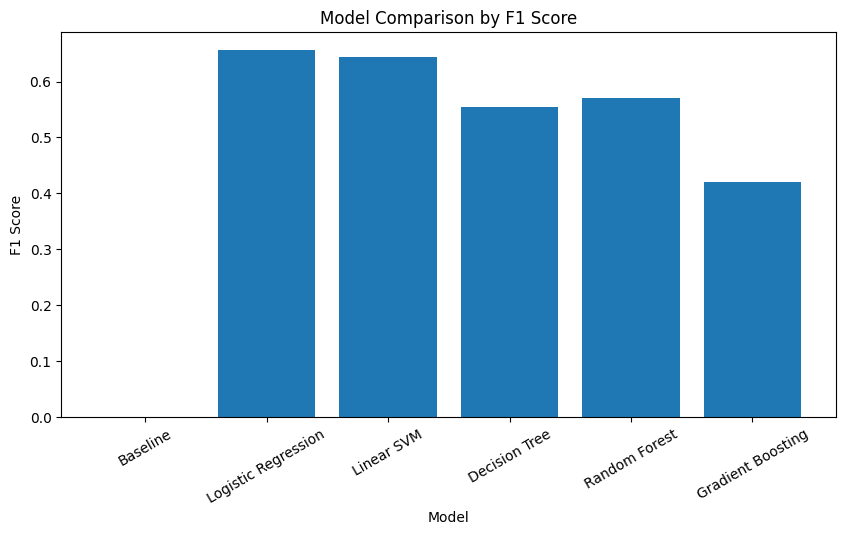

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["F1 Score"])
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=30)
plt.show()

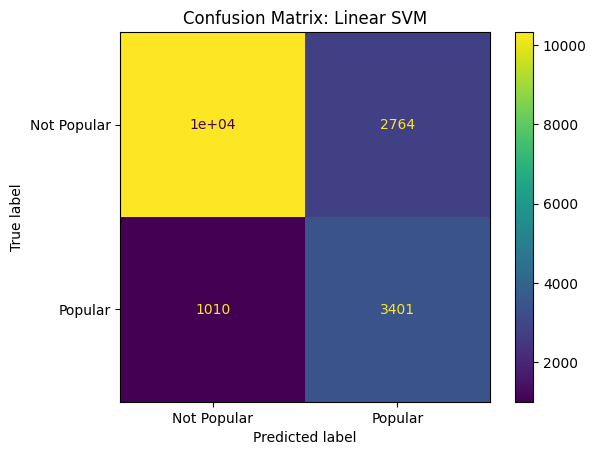

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_preds,
    display_labels=["Not Popular", "Popular"]
)

plt.title("Confusion Matrix: Linear SVM")
plt.show()

In [35]:
rf_classifier = rf_model.named_steps["model"]
rf_preprocess = rf_model.named_steps["preprocess"]

feature_names = rf_preprocess.get_feature_names_out()

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

rf_importance.head(20)

,Feature,Importance
5197,cat__Topic_obama,0.136272
5202,num__headline_length,0.079809
5195,cat__Topic_economy,0.069287
5204,num__headline_word_count,0.061674
5201,num__title_length,0.032914
5196,cat__Topic_microsoft,0.031279
683,cat__Source_CNN,0.028771
5203,num__title_word_count,0.028264
513,cat__Source_Breitbart News,0.025323
5207,num__publish_hour,0.024454


In [36]:
results.to_csv("model_comparison_results.csv", index=False)
rf_importance.to_csv("random_forest_feature_importance.csv", index=False)